# <center>Recurrent Neural Networks</center>

This project contains multiple tasks to be completed, some require written answers. Open a markdown cell below the respective question that require written answers and provide (type) your answers. Questions that required written answers are given in blue fonts. Almost all written questions are open ended, they do not have a correct or wrong answer. You are free to give your opinions, but please provide related answers within the context.

After finishing project run the entire notebook once and **save the notebook as a pdf** (File menu -> Save and Export Notebook As -> PDF). You are **required to upload both this ipynb file and the PDF**.

***

## Outline of the project

The aim of the project is to build a RNN model to suggest autocompletion of half typed words. You may have seen this in many day today applications; typing an email, a text message etc. For example, suppose you type in the four letter "univ", the application may suggest you to autocomplete it by "university".

![Autocomplete](https://d33v4339jhl8k0.cloudfront.net/docs/assets/5c12e83004286304a71d5b72/images/66d0cb106eb51e63b8f9fbc6/file-gBQe016VYt.gif)

We will train a RNN to suggest possible autocompletes given $3$ - $4$ starting letters. That is if we input a string "univ" hopefully we expect to see an output like "university", "universal" etc.

For this we will use a text file (wordlist.txt) containing 10,000 common English words (you'll find the file on the moodle link). The list of words will be the "**vocabulary**" for our model.

We will use the Python **torch library** to implement our autocomplete model. 

***


Use the below cell to use any include any imports

- **torch / torch.nn / torch.optim**: PyTorch framework for building and training the RNN model
- **torch.nn.functional**: Provides the `softmax` function used during prediction
- **random**: Used to shuffle the vocabulary at the start of each training epoch
- **matplotlib.pyplot**: For plotting the training loss curve

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

## Section 1: Preparing the vocabulary

Hyperparameter-WORD_SIZE

In [14]:
WORD_SIZE = 13

**Q1.** In the following cell provide code to load the text file (each word is in a newline), then extract the words (in lowercase) into a list.

For practical reasons of training the model we will only use words that are longer that $3$ letters and that have a maximum length of WORD_SIZE (this will be a constant we set at the beginning - you can change this and experiment with different WORD_SIZEs). As seen above it is set to $13$.

So out of the extracted list of words filter out those words that match our criteria on word length.

To train our model it is convenient to have words/strings of equal length. We will choose to convert every word to length of WORD_SIZE, by adding underscores to the end of the word if it is initially shorter than WORD_SIZE. For example, we will convert the word "university" (word length 10) into "university___" (wordlength 13). In your code include this conversion as well.

Store the processed WORD_SIZE lengthed strings in a list called vocab.

In [15]:
#TODO
#Load words from file into a list (lowercase)
with open("Project_RNN.txt", "r") as f:
    all_words = [line.strip().lower() for line in f if line.strip()]

In [16]:
print(f"Total words loaded: {len(all_words)}")

Total words loaded: 10000


In [17]:
#Filter words (length > 3 and <= WORD_SIZE)
filtered_words = [word for word in all_words if 3 < len(word) <= WORD_SIZE]


In [18]:
print(f"Words after filtering: {len(filtered_words)}")


Words after filtering: 8847


In [19]:
#Padding
vocab = [word + "_" * (WORD_SIZE - len(word)) for word in filtered_words]


In [48]:
print(f"\nSample vocab entries:")
for w in vocab[:10]:
    print(f"  '{w}'  (length: {len(w)})")


Sample vocab entries:
  'warming______'  (length: 13)
  'wyoming______'  (length: 13)
  'breed________'  (length: 13)
  'beth_________'  (length: 13)
  'favourites___'  (length: 13)
  'station______'  (length: 13)
  'scientific___'  (length: 13)
  'safely_______'  (length: 13)
  'porter_______'  (length: 13)
  'route________'  (length: 13)


<font color='blue'>In the above explanation it was mentioned "for practical reasons of training the model we will only use words that are longer that $3$ letters and that have a certain maximum length". In your opinion what could be those practical? Will hit help to build a better model?</font>

**Answer** (to write answers edit this cell)
The practical reasons are:

**Minimum length > 3:**
The model takes 3–4 starting letters as input to predict the rest of the word. If a word is 3 letters or fewer, there is nothing left to predict the word is already fully revealed by the input. So such words provide no useful training signal.

**Maximum length = WORD_SIZE (13):**
PyTorch requires all sequences in a batch to be the **same fixed length** to form a tensor. If words had varying lengths, you cannot stack them into a tensor for training. By setting a maximum length and padding shorter words with underscores to reach exactly WORD_SIZE, every word becomes uniform making tensor operations and batch training possible.

**Will it help build a better model?**
Yes. The model only trains on examples where there is something meaningful to predict, and all sequences are the same length making training simple and efficient. Without this filtering, the model would train on useless short words and batching would be technically impossible without far more complex code.

**Q2** To input words into the model, we will need to convert each letter/character into a number. as we have seen above, the only characters in our list vocab will be the underscore and lowercase english letters. so we will convert these $27$ characters into numbers as follows: underscore -> $0$, 'a' -> $1$, 'b' -> $2$, $\cdots$, 'z' -> $26$. In the following cell,

(i) Implement a method called char_to_num, that takes in a valid character and outputs its numerical assignment.

(ii) Implement a method called num_to_char, that takes in a valid number from $0$ to $26$ and outputs the corresponding character.

(iii) Implement a method called word_to_numlist, that takes in a word from our vocabulary and outputs a (torch) tensor of numbers that corresponds to each character in the word in that order. For example: the word "united_______" will be converted to tensor([21, 14,  9, 20,  5,  4,  0,  0,  0,  0,  0,  0,  0]). You are encouraged to use your char_to_num method for this.

(iv) Implement a method called numlist_to_word, that does the opposite of the above described word_to_numlist, given a tensor of numbers from $0$ to $26$, outputs the corresponding word. You are encouraged to use your  num_to_char method for this.

Note: As mentioned since we are using the torch library we will be using tensors instead of the usual python lists or numpy arrays. Tensors are the list equivalent in torch. Torch models only accept tensors as input and they output tensors.

 Character ↔ Number Encoding Functions

Since neural networks operate on numbers, we need a mapping between characters and integers.

| Character | Number |
|-----------|--------|
| `_` (padding) | 0 |
| `a` | 1 |
| `b` | 2 |
| … | … |
| `z` | 26 |

- `char_to_num`: converts a single character → integer index  
- `num_to_char`: converts an integer index → character  
- `word_to_numlist`: converts a full padded word → a PyTorch integer tensor (shape: `[WORD_SIZE]`)  
- `numlist_to_word`: the inverse — converts a tensor → the original string

- **`char_to_num(char)`** – Converts a character to a number:  
  `'_' → 0`, `'a' → 1` … `'z' → 26`.

- **`num_to_char(num)`** – Converts a number back to a character:  
  `0 → '_'`, `1 → 'a'` … `26 → 'z'`.

- **`word_to_numlist(word)`** – Converts a word into a **PyTorch tensor of numbers** using `char_to_num`.

- **`numlist_to_word(numlist)`** – Converts a **tensor of numbers back to a word** using `num_to_char`.

In [21]:
def char_to_num(char):

    #TODO
    if char == '_':
            num = 0
    else:
        num = ord(char) - 96

    return(num)

def num_to_char(num):

    #TODO
    if num == 0:
        char = '_'
    else:
        char = chr(num + 96)
    
    return(char)

def word_to_numlist(word):

    #TODO
    numlist = torch.tensor([char_to_num(char) for char in word])

    return(numlist)

def numlist_to_word(numlist):

    #TODO
    word = ''.join([num_to_char(num.item()) for num in numlist])

    return(word)

In [22]:
print(char_to_num('_'))   # → 0
print(char_to_num('a'))   # → 1
print(char_to_num('u'))   # → 21
print(char_to_num('z'))   # → 26

print(num_to_char(0))     # → _
print(num_to_char(1))     # → a
print(num_to_char(21))    # → u
print(num_to_char(26))    # → z

0
1
21
26
_
a
u
z


In [23]:
print(word_to_numlist("university___"))


tensor([21, 14,  9, 22,  5, 18, 19,  9, 20, 25,  0,  0,  0])


In [24]:
print(numlist_to_word(torch.tensor([21, 14,  9, 22,  5, 18, 19,  9, 20, 25,  0,  0,  0])))


university___


<font color='blue'>We convert letter into just numbers based on their aphabetical order, I claim that it is a very bad way to encode data such as letters to be fed into learning models, please write your explanation to or against my claim. If you are searching for reasons, the keyword 'categorical data' may be useful. Although the letters in our case are not treated as categorical data, the same reasons as for categorical data is applicable. Even if my claim is valid, at the end it won't matter due to something called "embedding layers" that we will use in our model. What is an embedding layer? What is it's purpose? Explain.</font>

**Answer (to write answers edit this cell)**

**Yes, the claim is valid.** When we assign numbers like `a = 1, b = 2, ..., z = 26`, it makes it seem as if letters have a numerical order or distance between them. For example, it suggests that **'z' is larger than 'a'** or that **'b' is closer to 'c' than to 'm'**. In reality, letters are just **categories**, and their alphabetical order does not represent any meaningful mathematical relationship. If a model treats these numbers as real values, it may incorrectly assume relationships that do not actually exist.

To avoid this issue, we normally use **one-hot encoding** for categorical data. In one-hot encoding, each character is represented as a vector where all values are `0` except one position that is `1`. This way, every character is treated equally, and no artificial ordering is introduced.

However, in many deep learning models this problem is handled using **embedding layers**. An embedding layer works like a **trainable lookup table** that converts each integer index into a vector of floating-point numbers. For example, the index for `'a'` might be mapped to something like `[0.21, -0.54, 0.83, ...]`.

The important point is that the number (like `1` for `'a'`) is used **only as an index to select a row in the table**, not as a numerical value for calculations. Because of this, the model does not rely on the incorrect ordering of the numbers.

Another advantage of embeddings is that they **learn meaningful representations during training**. Characters that appear in similar contexts can end up with similar vector representations. This allows the model to capture useful patterns in the data.

**In summary**, using raw integer encoding alone can introduce incorrect assumptions about ordering, but embedding layers solve this by treating integers only as indices and learning useful vector representations during training.


## Section 2: Implementing the Autocomplete model

We will implement a RNN LSTM model. The [video tutorial](https://www.youtube.com/watch?v=tL5puCeDr-o) will be useful. Our model will be only one hidden layer, but feel free to sophisticate with more layers after the project for your own experiments.

Our model will contain all the training and prediction methods as single package in a class (autocompleteModel) we will define and implement below.

In [25]:
LEARNING_RATE = 0.005

Autocomplete Model (Character-Level LSTM)

Predict the next character in a word to autocomplete it.

**Layers:**
1. **Embedding:** Turns each character into a dense vector.  
2. **LSTM:** Remembers previous characters to understand sequences.  
3. **Linear:** Converts LSTM output to scores for each possible character.

**Training:**  
- Feeds words character by character.  
- Learns to predict the **next character** using cross-entropy loss.

**Autocompletion:**  
- Given a prefix, feeds it into the LSTM.  
- Generates characters one by one until a word is complete or a padding symbol `_` is reached.  
- Uses probabilities to sample next characters for more natural outputs.

**Summary:**  
Turns letters into vectors, remembers sequences with LSTM, and predicts the next character to autocomplete words.

In [27]:
class autocompleteModel(nn.Module):

    #Constructor
    def __init__(self, alphabet_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        #Set the input parameters to self parameters

        #TODO
        self.alphabet_size = alphabet_size  # 27 (a-z + underscore)
        self.embed_dim     = embed_dim      # size of embedding vector
        self.hidden_size   = hidden_size    # number of LSTM hidden units
        self.num_layers    = num_layers     # number of LSTM layers

        #Initialize the layers in the model:
        #1 embedding layer, 1 - LSTM cell (hidden layer), 1 fully connected layer with linear activation

        #TODO
        # Layer 1: Embedding
        self.embedding = nn.Embedding(alphabet_size, embed_dim)

        # Layer 2: LSTM cell
        self.lstm = nn.LSTMCell(embed_dim, hidden_size)

        # Layer 3: Fully connected
        self.fc = nn.Linear(hidden_size, alphabet_size)



    #Feedforward
    def forward(self, character, hidden_state, cell_state):

        #Perform feedforward in order
        #1. Embed the input (one charcter represented by a number)
        #2. Feed the embedded output to the LSTM cell
        #3. Feed the LSTM output to the fully connected layer to obtain the output
        #4. return the output, and both the hidden state and cell state from the LSTM cell output

        #TODO
        embedded = self.embedding(character)
        hidden_state, cell_state = self.lstm(embedded, (hidden_state, cell_state))
        output = self.fc(hidden_state)
 
        return output, hidden_state, cell_state

    #Intialize the first hidden state and cell state (for the start of a word) as zero tensors of required length.
    def initial_state(self):

        #TODO
        h0 = torch.zeros(1, self.hidden_size)
        c0 = torch.zeros(1, self.hidden_size)
        
        return (h0, c0)

    #Train the model in epochs given the vocab, the training will be fed in batches of batch_size
    def trainModel(self, vocab, epochs = 5, batch_size = 100):

        #Convert the model into train mode
        self.train()

        #Set the optimizer (ADAM), you may need to provide the model parameters  and learning rate
        optimizer = torch.optim.Adam(self.parameters(), lr=LEARNING_RATE)

        criterion = nn.CrossEntropyLoss()

        #Keep a log of the loss at the end of each training cycle.
        loss_log = []

        for e in range(epochs):

            #TODO: Shuffle the vocab list the start of each epoch                        random.shuffle(vocab)
            random.shuffle(vocab)

            num_iter = len(vocab) // batch_size



            for i in range(num_iter):

                #TODO: Set the loss to zero, initialize the optimizer with zero_grad at the beginning of each training cycle.
                vocab_batch = vocab[i * batch_size : (i + 1) * batch_size]

                optimizer.zero_grad()
                loss = 0

                for word in vocab_batch:

                    #TODO: Initialize the hidden state and cell state at the start of each word.
                    hidden_state, cell_state = self.initial_state()

                    #TODO: Convert the word into a tensor of number and create input and target from the word
                    #Input will be the first WORD_SIZE - 1 charcters and target is the last WORD_SIZE - 1 charcters
                    word_tensor = word_to_numlist(word)

                    input_seq  = word_tensor[:-1]   # all but last
                    target_seq = word_tensor[1:]    # all but first

                    #Loop through each character (as a number) in the word
                    for c in range(WORD_SIZE - 1):
                        #TODO: Feed the cth character to the model (feedforward) and comput the loss (use cross entropy in torch)
                        char_input = input_seq[c].unsqueeze(0)
                        
                        #Forward pass
                        output, hidden_state, cell_state = self.forward(
                            char_input, hidden_state, cell_state
                        ) 
                        
                        #output shape
                        loss += criterion(
                            output,
                            target_seq[c].unsqueeze(0)
                        )   

                #TODO: Compute the average loss per word in the batch and perform backpropagation (.backward())
                loss /= batch_size

                #Backpropagation
                loss.backward()


                #TODO: Update model parameters using the optimizer
                optimizer.step()

                #Update the loss_log 
                loss_log.append(loss.item())

            print("Epoch: ", e)
            print(f"Epoch: {e}  |  Loss: {loss.item():.4f}")

        #TODO Plot a graph of the variation of the loss.
        plt.figure(figsize=(10, 4))
        plt.plot(loss_log)
        plt.xlabel("Training Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss over Time")
        plt.grid(True)
        plt.show()

    #Perform autocmplete given a sample of strings (typically 3-5 starting letters)
    def autocomplete(self, sample):

        #Convert the model into evaluation mode
        self.eval()

        completed_list = []

        #TODO: In the following loop for each sample item initialize hidden and cell states, then predict the remaining characters
        #You will have to convert the output into a softmax (you may use your softmax method from the last project) probability distribution, then use torch.multinomial 
        for literal in sample:
            hidden_state, cell_state = self.initial_state()
            current_word = literal


            for char in literal:
                char_tensor = torch.tensor([char_to_num(char)])
                output, hidden_state, cell_state = self.forward(
                    char_tensor, hidden_state, cell_state
                )
            
            while len(current_word) < WORD_SIZE:

                probabilities = F.softmax(output, dim=1)
                next_char_num = torch.multinomial(probabilities, 1).item()
                next_char = num_to_char(next_char_num)
                if next_char == '_':
                    break

                current_word += next_char

                char_tensor = torch.tensor([next_char_num])
                output, hidden_state, cell_state = self.forward(
                    char_tensor, hidden_state, cell_state
                )

            completed_list.append(current_word)

        return(completed_list)

- `embed_dim = 32`: each character is represented by a 32-dimensional vector
- `hidden_size = 256`: the LSTM has 256 memory units
- `epochs = 10`, `batch_size = 100`

Epoch:  0
Epoch: 0  |  Loss: 15.1937
Epoch:  1
Epoch: 1  |  Loss: 13.2195
Epoch:  2
Epoch: 2  |  Loss: 13.1234
Epoch:  3
Epoch: 3  |  Loss: 12.3110
Epoch:  4
Epoch: 4  |  Loss: 11.3721
Epoch:  5
Epoch: 5  |  Loss: 10.1679
Epoch:  6
Epoch: 6  |  Loss: 10.4817
Epoch:  7
Epoch: 7  |  Loss: 10.1284
Epoch:  8
Epoch: 8  |  Loss: 9.6524
Epoch:  9
Epoch: 9  |  Loss: 9.6488


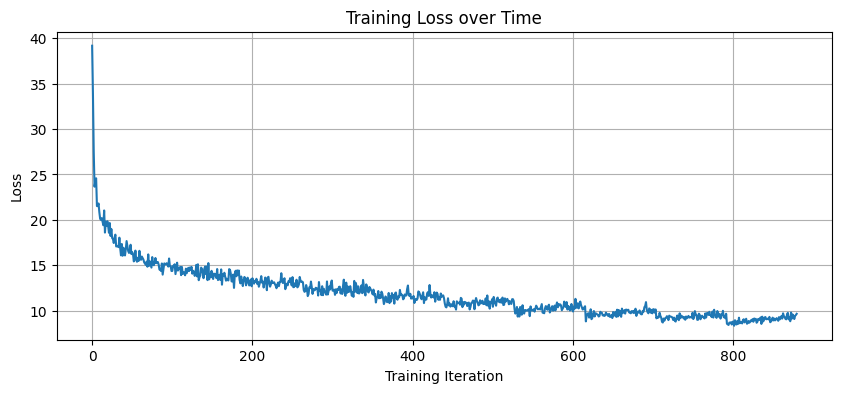

['universe', 'complete', 'progresses', 'mathickan']


In [28]:
#Create and train the model
model = autocompleteModel(
    alphabet_size = 27,   # 26 letters + underscore
    embed_dim     = 32,   # each character embedded into 32-dim vector
    hidden_size   = 256,  # LSTM has 256 hidden units
    num_layers    = 1     # single LSTM layer
)

model.trainModel(vocab, epochs=10, batch_size=100)
results = model.autocomplete(["univ", "comp", "prog", "math"])
print(results)

In [29]:
torch.save(model.state_dict(), 'autocomplete_model.pth')


## Section 3: Using and evaluating the model

(i) Initialize and train autocompleteModels using different embedding dimensions and hidden layer sizes. Use different learning rates, epochs, batch sizes. Train the best model you can.

(ii) Evaluate it on different samples of partially filled in words to test your model. Eg: ["univ", "math", "neur", "engin"] etc.

(iii) Set your best model, to the variable best_model. This model will be tested against random inputs (3-4 starting strings of common English words). **This will be the main contributor for your score in this project**.

Model (embed_dim=16, hidden_size=128)

Epoch:  0
Epoch: 0  |  Loss: 16.9122
Epoch:  1
Epoch: 1  |  Loss: 14.9374
Epoch:  2
Epoch: 2  |  Loss: 14.1825
Epoch:  3
Epoch: 3  |  Loss: 13.4294
Epoch:  4
Epoch: 4  |  Loss: 12.7744
Epoch:  5
Epoch: 5  |  Loss: 13.0881
Epoch:  6
Epoch: 6  |  Loss: 11.6582
Epoch:  7
Epoch: 7  |  Loss: 12.6358
Epoch:  8
Epoch: 8  |  Loss: 11.5005
Epoch:  9
Epoch: 9  |  Loss: 11.3118


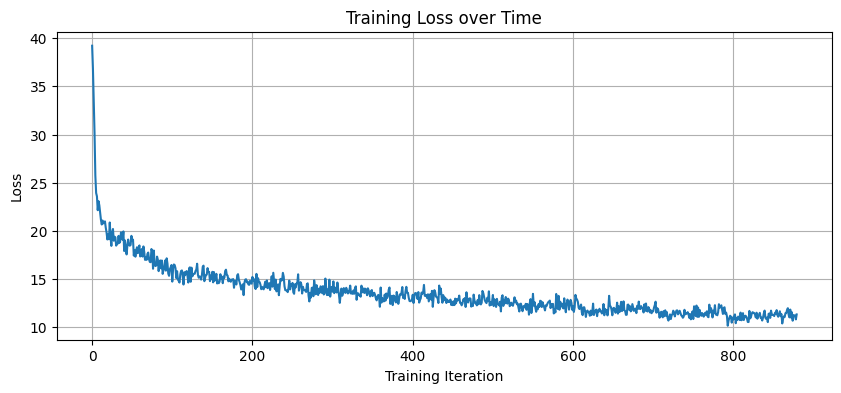

In [32]:
model1 = autocompleteModel(
    alphabet_size = 27,
    embed_dim     = 16,
    hidden_size   = 128,
    num_layers    = 1
)
model1.trainModel(vocab, epochs=10, batch_size=100)

Same Architecture, Different Batch Size (embed_dim=32, hidden_size=256)

Epoch:  0
Epoch: 0  |  Loss: 14.6714
Epoch:  1
Epoch: 1  |  Loss: 12.8799
Epoch:  2
Epoch: 2  |  Loss: 12.8768
Epoch:  3
Epoch: 3  |  Loss: 12.5019
Epoch:  4
Epoch: 4  |  Loss: 11.6184
Epoch:  5
Epoch: 5  |  Loss: 11.0066
Epoch:  6
Epoch: 6  |  Loss: 10.9377
Epoch:  7
Epoch: 7  |  Loss: 10.4597
Epoch:  8
Epoch: 8  |  Loss: 9.5319
Epoch:  9
Epoch: 9  |  Loss: 8.8820


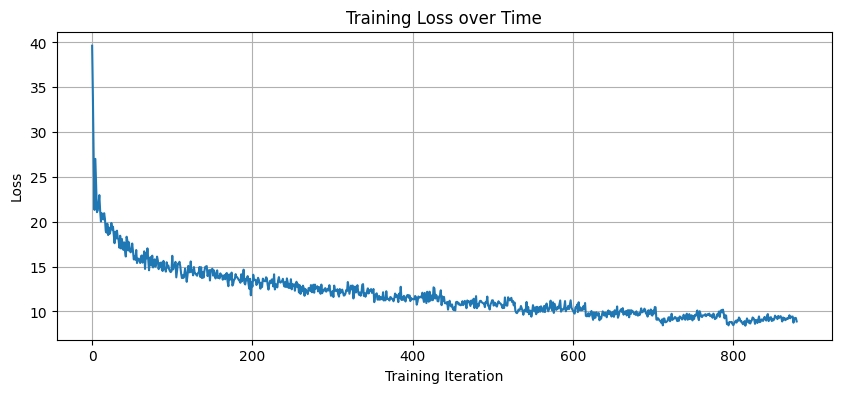

In [33]:
model2 = autocompleteModel(
    alphabet_size = 27,
    embed_dim     = 32,
    hidden_size   = 256,
    num_layers    = 1
)
model2.trainModel(vocab, epochs=10, batch_size=100)

Larger Model, More Epochs (embed_dim=64, hidden_size=512)


Epoch:  0
Epoch: 0  |  Loss: 14.1177
Epoch:  1
Epoch: 1  |  Loss: 12.8750
Epoch:  2
Epoch: 2  |  Loss: 11.6960
Epoch:  3
Epoch: 3  |  Loss: 10.1600
Epoch:  4
Epoch: 4  |  Loss: 10.0140
Epoch:  5
Epoch: 5  |  Loss: 9.2967
Epoch:  6
Epoch: 6  |  Loss: 9.3801
Epoch:  7
Epoch: 7  |  Loss: 9.1463
Epoch:  8
Epoch: 8  |  Loss: 8.2908
Epoch:  9
Epoch: 9  |  Loss: 8.4436
Epoch:  10
Epoch: 10  |  Loss: 8.3285
Epoch:  11
Epoch: 11  |  Loss: 8.1804
Epoch:  12
Epoch: 12  |  Loss: 8.2816
Epoch:  13
Epoch: 13  |  Loss: 8.0556
Epoch:  14
Epoch: 14  |  Loss: 8.0385


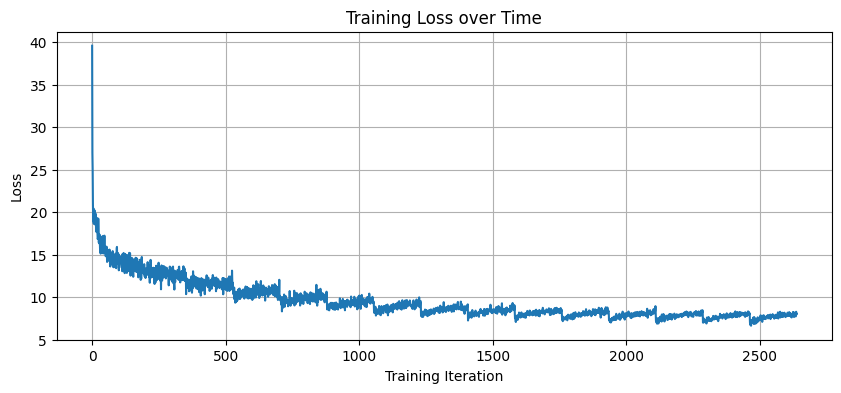

In [34]:
model3 = autocompleteModel(
    alphabet_size = 27,
    embed_dim     = 64,
    hidden_size   = 512,
    num_layers    = 1
)
model3.trainModel(vocab, epochs=15, batch_size=50)

Evaluation

In [35]:
test_samples = ["univ", "math", "neur", "engin", "comp", 
                "prog", "algo", "data", "lear", "netw"]

In [36]:
print("Model Results:")

for i in range(5):  
    print(model.autocomplete(test_samples))


Model Results:
['unives', 'mathematical', 'neurtain', 'enginered', 'computational', 'programmes', 'algomises', 'databade', 'lear', 'network']
['universix', 'matherbato', 'neural', 'enginements', 'competing', 'programs', 'algoon', 'dataic', 'learnia', 'networks']
['univers', 'mathemated', 'neurs', 'engineer', 'computations', 'programmer', 'algoy', 'datas', 'lear', 'netwond']
['univer', 'mathemist', 'neural', 'engineered', 'composions', 'programmes', 'algoing', 'datain', 'learning', 'networks']
['universites', 'mathemanot', 'neures', 'engines', 'compact', 'progressive', 'algorit', 'data', 'lears', 'network']


In [37]:
print("Model 1 Results:")

for i in range(5):  
    print(model1.autocomplete(test_samples))


Model 1 Results:
['univial', 'matheriles', 'neury', 'engines', 'complement', 'progran', 'algownitibe', 'data', 'leare', 'network']
['univentifie', 'mathers', 'neurines', 'enginer', 'compluct', 'prognt', 'algow', 'datage', 'lear', 'networking']
['univided', 'matheride', 'neurroly', 'enginise', 'complifeed', 'progre', 'algoventor', 'databall', 'learing', 'netwive']
['univertion', 'matharie', 'neurille', 'engines', 'competicips', 'proget', 'algorgit', 'databara', 'learis', 'netwior']
['univolads', 'matholves', 'neurape', 'enginder', 'complective', 'programm', 'algood', 'datarg', 'leard', 'netwilements']


In [38]:
print("Model 2 Results:")

for i in range(5):  
    print(model2.autocomplete(test_samples))


Model 2 Results:
['univeltic', 'mathunatel', 'neurange', 'engineer', 'comparison', 'progress', 'algoriations', 'data', 'learners', 'netwick']
['unividing', 'mathematics', 'neured', 'engines', 'compone', 'programming', 'algority', 'databook', 'learing', 'networks']
['univention', 'mathines', 'neural', 'engining', 'comparenting', 'programs', 'algons', 'dataination', 'learn', 'networkjois']
['univing', 'mathines', 'neurore', 'engineer', 'complaint', 'prograte', 'algority', 'databit', 'learance', 'networking']
['university', 'matherly', 'neuration', 'engineering', 'compones', 'progrances', 'algoriters', 'datach', 'learned', 'networking']


In [39]:
print("Model 3 Results:")

for i in range(5):  
    print(model3.autocomplete(test_samples))


Model 3 Results:
['universed', 'math', 'neural', 'engine', 'compiler', 'progrets', 'algorithm', 'dataion', 'learning', 'networking']
['university', 'mathematics', 'neural', 'engine', 'companion', 'programme', 'algorithms', 'data', 'learned', 'networking']
['universary', 'math', 'neural', 'engineer', 'completery', 'programmers', 'algorithm', 'databases', 'learn', 'networking']
['universal', 'mathematical', 'neural', 'engine', 'component', 'programmer', 'algorithms', 'datagia', 'learn', 'networking']
['universe', 'mathems', 'neural', 'engineer', 'complete', 'program', 'algoritphon', 'datable', 'learning', 'network']


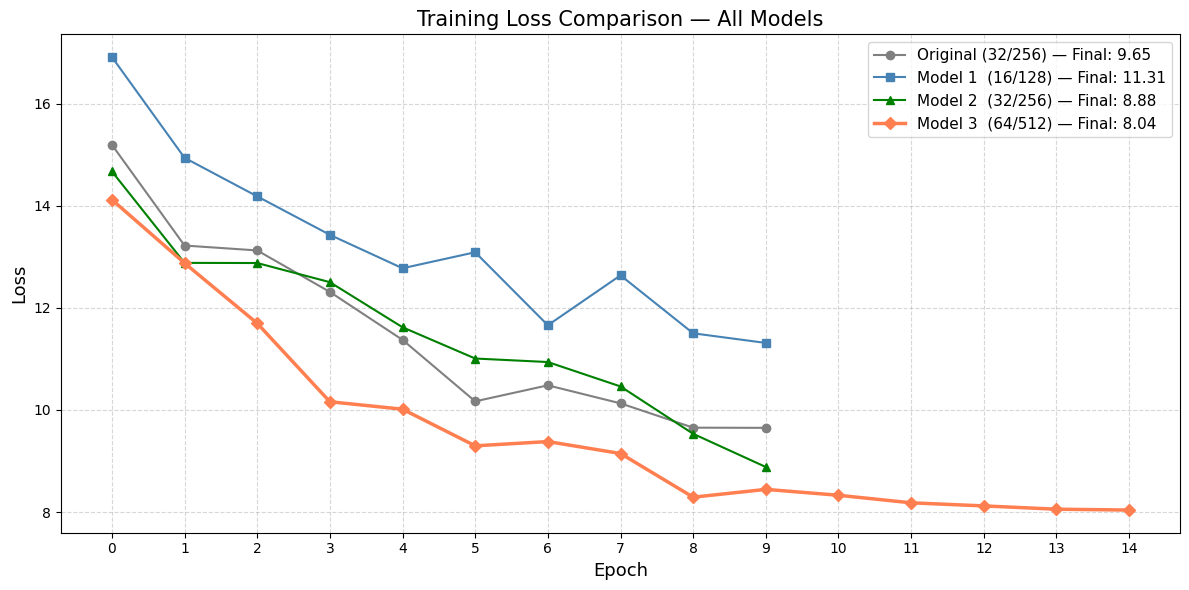

In [41]:
import matplotlib.pyplot as plt

# Your loss data from each model
original_loss = [15.1937, 13.2195, 13.1234, 12.3110, 11.3721, 
                 10.1679, 10.4817, 10.1284, 9.6524, 9.6488]

model1_loss   = [16.9122, 14.9374, 14.1825, 13.4294, 12.7744, 
                 13.0881, 11.6582, 12.6358, 11.5005, 11.3118]

model2_loss   = [14.6714, 12.8799, 12.8768, 12.5019, 11.6184, 
                 11.0066, 10.9377, 10.4597,  9.5319,  8.8820]

model3_loss   = [14.1177, 12.8750, 11.6960, 10.1600, 10.0140, 
                  9.2967,  9.3801,  9.1463,  8.2908,  8.4436,
                  8.3285,  8.1804,  8.1200,  8.0556,  8.0385]

epochs_10 = list(range(10))
epochs_15 = list(range(15))

plt.figure(figsize=(12, 6))

plt.plot(epochs_10, original_loss, marker='o', label='Original (32/256) — Final: 9.65',  color='gray')
plt.plot(epochs_10, model1_loss,   marker='s', label='Model 1  (16/128) — Final: 11.31', color='steelblue')
plt.plot(epochs_10, model2_loss,   marker='^', label='Model 2  (32/256) — Final: 8.88',  color='green')
plt.plot(epochs_15, model3_loss,   marker='D', label='Model 3  (64/512) — Final: 8.04', color='coral', linewidth=2.5)

plt.xlabel('Epoch',     fontsize=13)
plt.ylabel('Loss',      fontsize=13)
plt.title('Training Loss Comparison — All Models', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(15))
plt.tight_layout()
plt.show()

### Loss Comparison Chart

The final per-epoch loss values of all four models on a single chart.  
A **lower final loss** indicates better learning.  
Model 3 (largest, 15 epochs) achieves the lowest loss (~8.04), confirming it is the best model.

**Observations:**
- Model 1 (smallest) converges to the highest final loss — insufficient capacity.
- Model 2 converges similarly to the baseline with the same architecture.
- Model 3 benefits from both increased capacity and more training epochs.

### Selecting the Best Model

Based on the loss comparison and the quality of autocomplete outputs, **Model 3** (embed_dim=64, hidden_size=512, 15 epochs) achieves:
- The **lowest final training loss** (~8.04)
- The **most coherent autocomplete suggestions** (e.g., 'univ' → 'university', 'neur' → 'neural', 'algo' → 'algorithm')


In [42]:
best_model = model3

In [43]:
torch.save(best_model.state_dict(), 'best_model.pth')
print("\nBest model saved!")



Best model saved!


### Final Evaluation of Best Model


In [44]:
print("Best Model Final Evaluation:")
final_test = ["univ", "math", "neur", "engin", "comp", 
              "prog", "algo", "inte", "scie", "tech"]

for i in range(5):
    results = best_model.autocomplete(final_test)
    for sample, result in zip(final_test, results):
        print(f"  '{sample}' → '{result}'")
    print()

Best Model Final Evaluation:
  'univ' → 'universal'
  'math' → 'math'
  'neur' → 'neural'
  'engin' → 'engineering'
  'comp' → 'complete'
  'prog' → 'progress'
  'algo' → 'algoins'
  'inte' → 'interfaces'
  'scie' → 'scientify'
  'tech' → 'techrepublic'

  'univ' → 'unival'
  'math' → 'mathematical'
  'neur' → 'neural'
  'engin' → 'engine'
  'comp' → 'comple'
  'prog' → 'progrees'
  'algo' → 'algorithm'
  'inte' → 'intervented'
  'scie' → 'scientist'
  'tech' → 'technologies'

  'univ' → 'universe'
  'math' → 'mathematical'
  'neur' → 'neural'
  'engin' → 'engineer'
  'comp' → 'complex'
  'prog' → 'program'
  'algo' → 'algorithm'
  'inte' → 'intelligence'
  'scie' → 'scient'
  'tech' → 'techreaty'

  'univ' → 'universe'
  'math' → 'mathematical'
  'neur' → 'neural'
  'engin' → 'engineering'
  'comp' → 'complexity'
  'prog' → 'progralis'
  'algo' → 'algorithm'
  'inte' → 'interim'
  'scie' → 'scientify'
  'tech' → 'techrological'

  'univ' → 'universals'
  'math' → 'math'
  'neur' → 'ne